# 电商欺诈检测数据分析与可视化

## 项目概述

本 Notebook 对两个欺诈检测数据集进行完整的数据分析流程：

| 数据集 | 来源 | 样本量 | 欺诈率 | 说明 |
|--------|------|--------|--------|------|
| 电商刷单数据 | 项目内置 | 10,000 | 0.95% | 电商刷单行为检测 |
| 信用卡欺诈数据 | Kaggle (ULB) | 284,807 | 0.17% | 信用卡欺诈交易检测 |

## 目录

1. **数据收集** — 加载与概览
2. **数据清洗** — 缺失值/重复值/异常值/类型修正
3. **数据分析** — 统计分析/维度分析/对比分析
4. **数据可视化** — 图表展示

---
## 1. 数据收集 (Data Collection)

### 1.1 导入库与环境配置

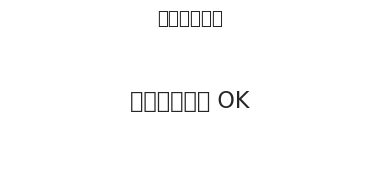

环境配置完成（中文已启用）


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib

# 配置中文字体（优先使用系统已安装的中文字体）
warnings.filterwarnings('ignore')

# 清除字体缓存并设置中文字体
matplotlib.font_manager._load_fontmanager(try_read_cache=False)
plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'Noto Sans CJK SC', 'DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
sns.set_context("notebook", font_scale=1.1)

# 测试中文显示
fig, ax = plt.subplots(figsize=(4, 2))
ax.text(0.5, 0.5, '中文字体测试 OK', ha='center', va='center', fontsize=16)
ax.set_title('中文标题测试')
ax.axis('off')
plt.tight_layout()
plt.show()
plt.close()

print('环境配置完成（中文已启用）')

### 1.2 加载电商刷单数据集

In [33]:
# 加载电商刷单数据
ecom_df = pd.read_csv('/root/ecommerce_fraud_detection/backend/data/ecommerce_transactions.csv')

print(f'电商刷单数据集: {ecom_df.shape[0]} 行, {ecom_df.shape[1]} 列')
print(f'字段: {list(ecom_df.columns)}')
print(f'欺诈样本: {ecom_df["is_cheat"].sum()} 条 ({ecom_df["is_cheat"].mean()*100:.2f}%)')
ecom_df.head()

电商刷单数据集: 10000 行, 7 列
字段: ['user_id', 'order_id', 'amount', 'time_diff', 'order_time', 'device_type', 'is_cheat']
欺诈样本: 95 条 (0.95%)


,user_id,order_id,amount,time_diff,order_time,device_type,is_cheat
0,U008553,O00008553,1653.44,366.757320,16,H5,0
1,SC10065,SC0010065,1.94,2.231243,7,H5,1
2,U006946,O00006946,1215.34,474.983477,8,PC,0
3,U008858,O00008858,1763.40,89.005529,17,Android,0
4,U007101,O00007101,156.61,75.833277,20,Android,0


### 1.3 加载信用卡欺诈数据集

In [34]:
# 加载信用卡欺诈数据
cc_df = pd.read_csv('/root/ecommerce_fraud_detection/backend/data/creditcard_raw.csv')

print(f'信用卡欺诈数据集: {cc_df.shape[0]} 行, {cc_df.shape[1]} 列')
print(f'字段: {list(cc_df.columns)}')
print(f'欺诈样本: {cc_df["Class"].sum()} 条 ({cc_df["Class"].mean()*100:.4f}%)')
cc_df.head()

信用卡欺诈数据集: 284807 行, 31 列
字段: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
欺诈样本: 492 条 (0.1727%)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 1.4 数据集基本信息概览

In [35]:
print('='*60)
print('电商刷单数据集 - 基本信息')
print('='*60)
print(ecom_df.info())
print()
print(ecom_df.describe())

电商刷单数据集 - 基本信息
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   user_id      10000 non-null  str    
 1   order_id     10000 non-null  str    
 2   amount       10000 non-null  float64
 3   time_diff    10000 non-null  float64
 4   order_time   10000 non-null  int64  
 5   device_type  10000 non-null  str    
 6   is_cheat     10000 non-null  int64  
dtypes: float64(2), int64(2), str(3)
memory usage: 547.0 KB
None

             amount     time_diff    order_time      is_cheat
count  10000.000000  10000.000000  10000.000000  10000.000000
mean    1483.452721    251.393876     12.054000      0.009500
std      877.875883    144.161424      6.641106      0.097009
min        1.000000      0.147960      1.000000      0.000000
25%      716.780000    126.108908      6.000000      0.000000
50%     1481.630000    250.734133     12.000000      0.000000
75%     224

In [5]:
print('='*60)
print('信用卡欺诈数据集 - 基本信息')
print('='*60)
print(cc_df.info())
print()
print(cc_df[['Time', 'Amount', 'Class']].describe())

信用卡欺诈数据集 - 基本信息
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21  

---
## 2. 数据清洗 (Data Cleaning)

### 2.1 缺失值检测与处理

In [6]:
# 电商数据缺失值
print('电商刷单数据 - 缺失值统计:')
ecom_missing = ecom_df.isnull().sum()
ecom_missing_pct = (ecom_df.isnull().sum() / len(ecom_df) * 100).round(2)
ecom_missing_report = pd.DataFrame({'缺失数': ecom_missing, '缺失率(%)': ecom_missing_pct})
print(ecom_missing_report)
print(f'总缺失值: {ecom_missing.sum()}')
print()

电商刷单数据 - 缺失值统计:
             缺失数  缺失率(%)
user_id        0     0.0
order_id       0     0.0
amount         0     0.0
time_diff      0     0.0
order_time     0     0.0
device_type    0     0.0
is_cheat       0     0.0
总缺失值: 0



In [7]:
# 信用卡数据缺失值
print('信用卡欺诈数据 - 缺失值统计:')
cc_missing = cc_df.isnull().sum()
cc_missing_pct = (cc_df.isnull().sum() / len(cc_df) * 100).round(2)
cc_missing_report = pd.DataFrame({'缺失数': cc_missing, '缺失率(%)': cc_missing_pct})
print(cc_missing_report[cc_missing_report['缺失数'] > 0])
if cc_missing.sum() == 0:
    print('无缺失值')
print(f'总缺失值: {cc_missing.sum()}')

信用卡欺诈数据 - 缺失值统计:
Empty DataFrame
Columns: [缺失数, 缺失率(%)]
Index: []
无缺失值
总缺失值: 0


In [8]:
# 处理缺失值（如有）
if ecom_missing.sum() > 0:
    ecom_df.dropna(inplace=True)
    print(f'电商数据: 删除缺失值后剩余 {len(ecom_df)} 行')
else:
    print('电商数据: 无缺失值，无需处理')

if cc_missing.sum() > 0:
    cc_df.dropna(inplace=True)
    print(f'信用卡数据: 删除缺失值后剩余 {len(cc_df)} 行')
else:
    print('信用卡数据: 无缺失值，无需处理')

电商数据: 无缺失值，无需处理
信用卡数据: 无缺失值，无需处理


### 2.2 重复值检测与处理

In [9]:
# 重复值检测
ecom_dup = ecom_df.duplicated().sum()
cc_dup = cc_df.duplicated().sum()

print(f'电商刷单数据 - 重复行数: {ecom_dup} ({ecom_dup/len(ecom_df)*100:.2f}%)')
print(f'信用卡欺诈数据 - 重复行数: {cc_dup} ({cc_dup/len(cc_df)*100:.2f}%)')
print()

# 处理重复值
if ecom_dup > 0:
    ecom_df.drop_duplicates(inplace=True)
    print(f'电商数据: 删除重复值后剩余 {len(ecom_df)} 行')
else:
    print('电商数据: 无重复值')

if cc_dup > 0:
    cc_df.drop_duplicates(inplace=True)
    print(f'信用卡数据: 删除重复值后剩余 {len(cc_df)} 行')
else:
    print('信用卡数据: 无重复值')

电商刷单数据 - 重复行数: 0 (0.00%)
信用卡欺诈数据 - 重复行数: 1081 (0.38%)

电商数据: 无重复值
信用卡数据: 删除重复值后剩余 283726 行


### 2.3 异常值检测

In [10]:
def detect_outliers_iqr(df, column):
    """使用 IQR 方法检测异常值"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return len(outliers), lower, upper

# 电商数据异常值检测
print('电商刷单数据 - IQR异常值检测:')
for col in ['amount', 'time_diff']:
    count, lower, upper = detect_outliers_iqr(ecom_df, col)
    print(f'  {col}: {count} 个异常值 (范围: [{lower:.2f}, {upper:.2f}])')

print()

# 信用卡数据异常值检测
print('信用卡欺诈数据 - IQR异常值检测:')
for col in ['Amount', 'Time']:
    count, lower, upper = detect_outliers_iqr(cc_df, col)
    print(f'  {col}: {count} 个异常值 (范围: [{lower:.2f}, {upper:.2f}])')

电商刷单数据 - IQR异常值检测:
  amount: 0 个异常值 (范围: [-1582.33, 4548.63])
  time_diff: 0 个异常值 (范围: [-250.23, 753.34])

信用卡欺诈数据 - IQR异常值检测:
  Amount: 31685 个异常值 (范围: [-102.27, 185.38])
  Time: 0 个异常值 (范围: [-73435.12, 266937.88])


### 2.4 数据类型修正

In [11]:
# 电商数据类型修正
ecom_df['order_time'] = ecom_df['order_time'].astype(int)
ecom_df['is_cheat'] = ecom_df['is_cheat'].astype(int)
ecom_df['device_type'] = ecom_df['device_type'].astype('category')

print('电商数据类型修正完成:')
print(ecom_df.dtypes)
print()

# 信用卡数据类型修正
cc_df['Class'] = cc_df['Class'].astype(int)

print('信用卡数据类型修正完成:')
print(cc_df[['Time', 'Amount', 'Class']].dtypes)

电商数据类型修正完成:
user_id             str
order_id            str
amount          float64
time_diff       float64
order_time        int64
device_type    category
is_cheat          int64
dtype: object

信用卡数据类型修正完成:
Time      float64
Amount    float64
Class       int64
dtype: object


### 2.5 清洗后数据质量报告

In [12]:
print('='*60)
print('数据清洗完成 - 质量报告')
print('='*60)
print()
print(f'电商刷单数据:')
print(f'  样本量: {len(ecom_df)}')
print(f'  缺失值: {ecom_df.isnull().sum().sum()}')
print(f'  重复行: {ecom_df.duplicated().sum()}')
print(f'  欺诈比例: {ecom_df["is_cheat"].mean()*100:.2f}%')
print()
print(f'信用卡欺诈数据:')
print(f'  样本量: {len(cc_df)}')
print(f'  缺失值: {cc_df.isnull().sum().sum()}')
print(f'  重复行: {cc_df.duplicated().sum()}')
print(f'  欺诈比例: {cc_df["Class"].mean()*100:.4f}%')

数据清洗完成 - 质量报告

电商刷单数据:
  样本量: 10000
  缺失值: 0
  重复行: 0
  欺诈比例: 0.95%

信用卡欺诈数据:
  样本量: 283726
  缺失值: 0
  重复行: 0
  欺诈比例: 0.1667%


---
## 3. 数据分析 (Data Analysis)

### 3.1 单变量统计分析

In [13]:
# 电商数据数值特征统计
print('电商刷单数据 - 数值特征统计:')
ecom_stats = ecom_df[['amount', 'time_diff', 'order_time']].describe().T
ecom_stats['skew'] = ecom_df[['amount', 'time_diff', 'order_time']].skew()
ecom_stats['kurtosis'] = ecom_df[['amount', 'time_diff', 'order_time']].kurtosis()
print(ecom_stats.round(2))

电商刷单数据 - 数值特征统计:
              count     mean     std   min     25%      50%      75%      max  \
amount      10000.0  1483.45  877.88  1.00  716.78  1481.63  2249.52  2999.47   
time_diff   10000.0   251.39  144.16  0.15  126.11   250.73   377.00   499.98   
order_time  10000.0    12.05    6.64  1.00    6.00    12.00    18.00    23.00   

            skew  kurtosis  
amount      0.00     -1.21  
time_diff  -0.01     -1.22  
order_time  0.00     -1.20  


In [14]:
# 信用卡数据数值特征统计
print('信用卡欺诈数据 - Amount 统计:')
cc_amount_stats = cc_df['Amount'].describe()
print(cc_amount_stats)
print(f'偏度: {cc_df["Amount"].skew():.2f}')
print(f'峰度: {cc_df["Amount"].kurtosis():.2f}')

信用卡欺诈数据 - Amount 统计:
count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64
偏度: 16.98
峰度: 844.47


### 3.2 标签分布分析

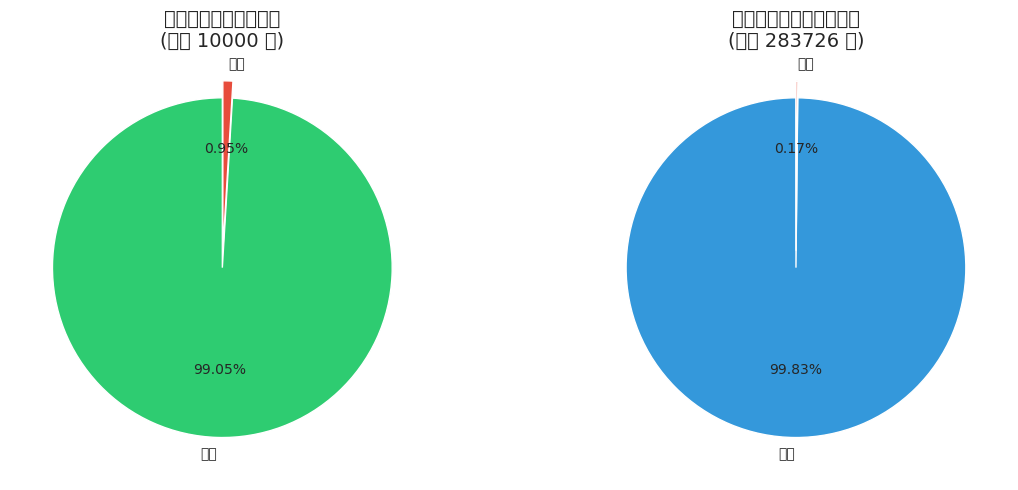

电商数据 - 正常: 9905, 欺诈: 95, 比例: 1:104
信用卡数据 - 正常: 283253, 欺诈: 473, 比例: 1:598


In [15]:
# 标签分布对比
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 电商数据
ecom_counts = ecom_df['is_cheat'].value_counts()
colors_ecom = ['#2ecc71', '#e74c3c']
axes[0].pie(ecom_counts, labels=['正常', '欺诈'], autopct='%1.2f%%', 
            colors=colors_ecom, startangle=90, explode=(0, 0.1))
axes[0].set_title(f'电商刷单数据标签分布\n(总计 {len(ecom_df)} 条)', fontsize=14)

# 信用卡数据
cc_counts = cc_df['Class'].value_counts()
colors_cc = ['#3498db', '#e74c3c']
axes[1].pie(cc_counts, labels=['正常', '欺诈'], autopct='%1.2f%%', 
            colors=colors_cc, startangle=90, explode=(0, 0.1))
axes[1].set_title(f'信用卡欺诈数据标签分布\n(总计 {len(cc_df)} 条)', fontsize=14)

plt.tight_layout()
plt.show()

print(f'电商数据 - 正常: {ecom_counts[0]}, 欺诈: {ecom_counts[1]}, 比例: 1:{ecom_counts[0]//ecom_counts[1]}')
print(f'信用卡数据 - 正常: {cc_counts[0]}, 欺诈: {cc_counts[1]}, 比例: 1:{cc_counts[0]//cc_counts[1]}')

### 3.3 特征相关性分析

In [16]:
# 电商数据相关性
ecom_corr = ecom_df[['amount', 'time_diff', 'order_time', 'is_cheat']].corr()
print('电商刷单数据 - 特征相关性矩阵:')
print(ecom_corr.round(3))
print()
print('与欺诈标签(is_cheat)的相关性:')
print(ecom_corr['is_cheat'].drop('is_cheat').sort_values(ascending=False))

电商刷单数据 - 特征相关性矩阵:
            amount  time_diff  order_time  is_cheat
amount       1.000      0.023       0.009    -0.165
time_diff    0.023      1.000      -0.003    -0.169
order_time   0.009     -0.003       1.000    -0.003
is_cheat    -0.165     -0.169      -0.003     1.000

与欺诈标签(is_cheat)的相关性:
order_time   -0.002814
amount       -0.165357
time_diff    -0.169083
Name: is_cheat, dtype: float64


In [17]:
# 信用卡数据相关性（选取相关性最高的特征）
cc_corr = cc_df.corr()
print('信用卡欺诈数据 - 与Class标签相关性 Top 10:')
cc_class_corr = cc_corr['Class'].drop('Class').abs().sort_values(ascending=False)
print(cc_class_corr.head(10).round(4))

信用卡欺诈数据 - 与Class标签相关性 Top 10:
V17    0.3135
V14    0.2934
V12    0.2507
V10    0.2070
V16    0.1872
V3     0.1823
V7     0.1723
V11    0.1491
V4     0.1293
V18    0.1053
Name: Class, dtype: float64


### 3.4 电商数据维度分析

In [18]:
# 设备类型分析
device_analysis = ecom_df.groupby('device_type').agg(
    订单数=('is_cheat', 'count'),
    欺诈数=('is_cheat', 'sum'),
    欺诈率=('is_cheat', 'mean'),
    平均金额=('amount', 'mean'),
    平均时间间隔=('time_diff', 'mean')
).round(3)
device_analysis['欺诈率'] = (device_analysis['欺诈率'] * 100).round(2)
print('设备类型维度分析:')
print(device_analysis)

设备类型维度分析:
              订单数  欺诈数  欺诈率      平均金额   平均时间间隔
device_type                                   
Android      2444   17  0.7  1520.839  251.432
H5           2568   23  0.9  1442.692  254.121
PC           2522   33  1.3  1461.291  249.741
iOS          2466   22  0.9  1511.512  250.206


In [19]:
# 时段分析
ecom_df['hour_bin'] = pd.cut(ecom_df['order_time'], 
                              bins=[0, 6, 12, 18, 24], 
                              labels=['凌晨(0-6)', '上午(6-12)', '下午(12-18)', '晚上(18-24)'],
                              right=False)

time_analysis = ecom_df.groupby('hour_bin', observed=False).agg(
    订单数=('is_cheat', 'count'),
    欺诈数=('is_cheat', 'sum'),
    欺诈率=('is_cheat', 'mean'),
    平均金额=('amount', 'mean')
).round(3)
time_analysis['欺诈率'] = (time_analysis['欺诈率'] * 100).round(2)
print('时段维度分析:')
print(time_analysis)

时段维度分析:
            订单数  欺诈数  欺诈率      平均金额
hour_bin                           
凌晨(0-6)    2131   17  0.8  1502.865
上午(6-12)   2638   30  1.1  1433.847
下午(12-18)  2579   23  0.9  1506.798
晚上(18-24)  2652   25  0.9  1494.495


In [20]:
# 金额区间分析
ecom_df['amount_bin'] = pd.cut(ecom_df['amount'], 
                                bins=[0, 500, 1000, 1500, 2000, 3000],
                                labels=['0-500', '500-1000', '1000-1500', '1500-2000', '2000-3000'])

amount_analysis = ecom_df.groupby('amount_bin', observed=False).agg(
    订单数=('is_cheat', 'count'),
    欺诈数=('is_cheat', 'sum'),
    欺诈率=('is_cheat', 'mean')
).round(3)
amount_analysis['欺诈率'] = (amount_analysis['欺诈率'] * 100).round(2)
print('金额区间分析:')
print(amount_analysis)

金额区间分析:
             订单数  欺诈数  欺诈率
amount_bin                
0-500       1771   95  5.4
500-1000    1656    0  0.0
1000-1500   1634    0  0.0
1500-2000   1652    0  0.0
2000-3000   3287    0  0.0


### 3.5 信用卡数据分析

In [21]:
# 信用卡金额分布对比
print('信用卡交易金额 - 正常 vs 欺诈:')
cc_normal = cc_df[cc_df['Class'] == 0]['Amount']
cc_fraud = cc_df[cc_df['Class'] == 1]['Amount']

compare_df = pd.DataFrame({
    '正常交易': cc_normal.describe(),
    '欺诈交易': cc_fraud.describe()
}).round(2)
print(compare_df)

信用卡交易金额 - 正常 vs 欺诈:
            正常交易     欺诈交易
count  283253.00   473.00
mean       88.41   123.87
std       250.38   260.21
min         0.00     0.00
25%         5.67     1.00
50%        22.00     9.82
75%        77.46   105.89
max     25691.16  2125.87


In [22]:
# 信用卡时间维度分析
cc_df['hour'] = (cc_df['Time'] % 86400 / 3600).astype(int)

cc_time_analysis = cc_df.groupby('hour').agg(
    交易数=('Class', 'count'),
    欺诈数=('Class', 'sum'),
    欺诈率=('Class', 'mean')
).round(4)
cc_time_analysis['欺诈率'] = (cc_time_analysis['欺诈率'] * 100).round(2)
print('信用卡 - 每小时交易分析:')
print(cc_time_analysis)

信用卡 - 每小时交易分析:
        交易数  欺诈数   欺诈率
hour                  
0      7647    6  0.08
1      4208   10  0.24
2      3308   48  1.45
3      3487   17  0.49
4      2204   23  1.04
5      2988   11  0.37
6      4082    9  0.22
7      7233   23  0.32
8     10232    9  0.09
9     15767   16  0.10
10    16548    8  0.05
11    16781   53  0.32
12    15378   17  0.11
13    15323   17  0.11
14    16520   23  0.14
15    16374   26  0.16
16    16396   22  0.13
17    16130   28  0.17
18    16959   28  0.17
19    15566   19  0.12
20    16705   18  0.11
21    17629   16  0.09
22    15378    9  0.06
23    10883   17  0.16


### 3.6 两个数据集欺诈模式对比

In [23]:
# 对比总结
print('='*60)
print('两个数据集欺诈模式对比')
print('='*60)
print()

ecom_normal_amount = ecom_df[ecom_df['is_cheat']==0]['amount'].mean()
ecom_fraud_amount = ecom_df[ecom_df['is_cheat']==1]['amount'].mean()

cc_normal_amount = cc_df[cc_df['Class']==0]['Amount'].mean()
cc_fraud_amount = cc_df[cc_df['Class']==1]['Amount'].mean()

comparison = pd.DataFrame({
    '指标': ['样本量', '欺诈率', '正常交易平均金额', '欺诈交易平均金额', '金额差异倍数'],
    '电商刷单数据': [
        f'{len(ecom_df):,}', 
        f'{ecom_df["is_cheat"].mean()*100:.2f}%',
        f'{ecom_normal_amount:.2f}',
        f'{ecom_fraud_amount:.2f}',
        f'{ecom_fraud_amount/ecom_normal_amount:.2f}x'
    ],
    '信用卡欺诈数据': [
        f'{len(cc_df):,}', 
        f'{cc_df["Class"].mean()*100:.4f}%',
        f'{cc_normal_amount:.2f}',
        f'{cc_fraud_amount:.2f}',
        f'{cc_fraud_amount/cc_normal_amount:.2f}x'
    ]
})
print(comparison.to_string(index=False))

两个数据集欺诈模式对比

      指标  电商刷单数据 信用卡欺诈数据
     样本量  10,000 283,726
     欺诈率   0.95% 0.1667%
正常交易平均金额 1497.67   88.41
欺诈交易平均金额    1.28  123.87
  金额差异倍数   0.00x   1.40x


---
## 4. 数据可视化 (Data Visualization)

### 4.1 交易金额分布直方图（正常 vs 欺诈）

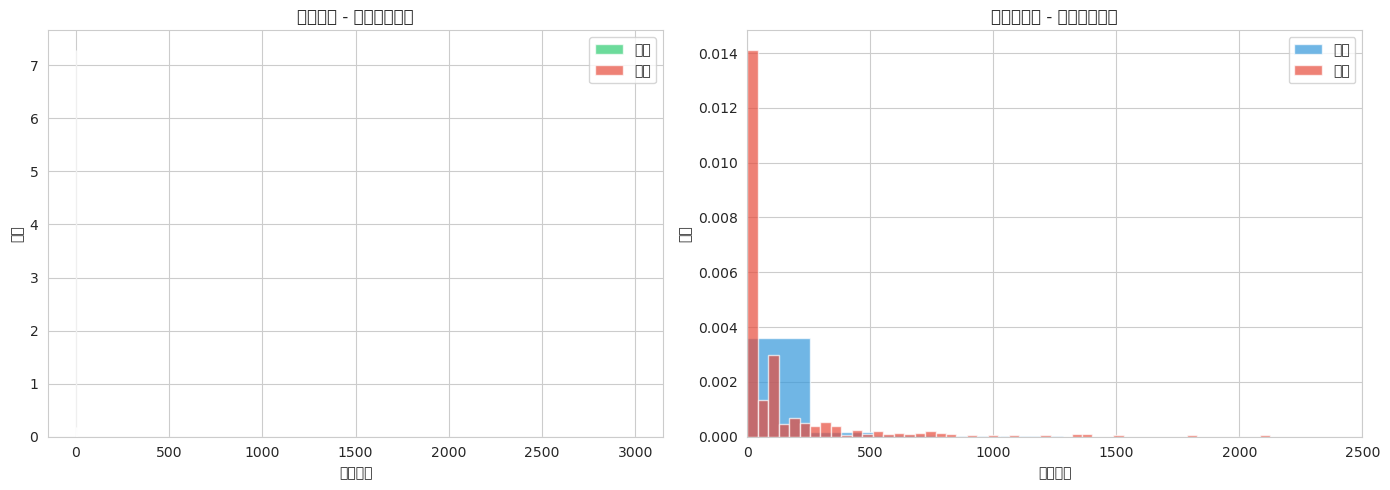

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 电商数据金额分布
axes[0].hist(ecom_df[ecom_df['is_cheat']==0]['amount'], bins=50, alpha=0.7, 
             label='正常', color='#2ecc71', density=True)
axes[0].hist(ecom_df[ecom_df['is_cheat']==1]['amount'], bins=30, alpha=0.7, 
             label='欺诈', color='#e74c3c', density=True)
axes[0].set_xlabel('交易金额')
axes[0].set_ylabel('密度')
axes[0].set_title('电商刷单 - 交易金额分布')
axes[0].legend()

# 信用卡数据金额分布
axes[1].hist(cc_df[cc_df['Class']==0]['Amount'], bins=100, alpha=0.7, 
             label='正常', color='#3498db', density=True)
axes[1].hist(cc_df[cc_df['Class']==1]['Amount'], bins=50, alpha=0.7, 
             label='欺诈', color='#e74c3c', density=True)
axes[1].set_xlabel('交易金额')
axes[1].set_ylabel('密度')
axes[1].set_title('信用卡欺诈 - 交易金额分布')
axes[1].legend()
axes[1].set_xlim(0, 2500)

plt.tight_layout()
plt.show()

### 4.2 特征相关性热力图

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 电商数据相关性热力图
ecom_corr_cols = ['amount', 'time_diff', 'order_time', 'is_cheat']
sns.heatmap(ecom_df[ecom_corr_cols].corr(), annot=True, fmt='.2f', 
            cmap='RdYlGn_r', center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('电商刷单数据 - 特征相关性')

# 信用卡数据相关性热力图（选取部分特征）
cc_selected = ['V1', 'V2', 'V3', 'V4', 'V7', 'V10', 'V11', 'V12', 'V14', 'V17', 'Amount', 'Class']
sns.heatmap(cc_df[cc_selected].corr(), annot=True, fmt='.2f', 
            cmap='RdYlGn_r', center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('信用卡欺诈数据 - 特征相关性')

plt.tight_layout()
plt.show()

### 4.3 电商：设备类型 × 欺诈率柱状图

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 设备类型订单数
device_counts = ecom_df.groupby('device_type', observed=False)['is_cheat'].count()
axes[0].bar(device_counts.index, device_counts.values, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
axes[0].set_xlabel('设备类型')
axes[0].set_ylabel('订单数')
axes[0].set_title('各设备类型订单数量')
for i, v in enumerate(device_counts.values):
    axes[0].text(i, v+50, str(v), ha='center', fontsize=10)

# 设备类型欺诈率
device_fraud_rate = ecom_df.groupby('device_type', observed=False)['is_cheat'].mean() * 100
bars = axes[1].bar(device_fraud_rate.index, device_fraud_rate.values, 
                   color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])
axes[1].set_xlabel('设备类型')
axes[1].set_ylabel('欺诈率 (%)')
axes[1].set_title('各设备类型欺诈率')
for i, v in enumerate(device_fraud_rate.values):
    axes[1].text(i, v+0.05, f'{v:.2f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### 4.4 电商：时段分布 × 欺诈率折线图

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 5))

hourly_stats = ecom_df.groupby('order_time').agg(
    order_count=('is_cheat', 'count'),
    fraud_rate=('is_cheat', 'mean')
)
hourly_stats['fraud_rate'] = hourly_stats['fraud_rate'] * 100

# 订单量柱状图
color1 = '#3498db'
ax1.bar(hourly_stats.index, hourly_stats['order_count'], color=color1, alpha=0.6, label='订单量')
ax1.set_xlabel('小时 (0-23)')
ax1.set_ylabel('订单量', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(range(0, 24))

# 欺诈率折线图
ax2 = ax1.twinx()
color2 = '#e74c3c'
ax2.plot(hourly_stats.index, hourly_stats['fraud_rate'], color=color2, 
         marker='o', linewidth=2, label='欺诈率')
ax2.set_ylabel('欺诈率 (%)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('电商数据 - 24小时订单量与欺诈率分布', fontsize=14)
plt.tight_layout()
plt.show()

### 4.5 信用卡：时间维度欺诈密度图

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 正常交易时间分布
cc_normal_hours = cc_df[cc_df['Class']==0]['hour']
cc_fraud_hours = cc_df[cc_df['Class']==1]['hour']

axes[0].hist(cc_normal_hours, bins=24, alpha=0.7, color='#3498db', edgecolor='white')
axes[0].set_xlabel('小时')
axes[0].set_ylabel('交易数')
axes[0].set_title('信用卡正常交易 - 时间分布')

axes[1].hist(cc_fraud_hours, bins=24, alpha=0.7, color='#e74c3c', edgecolor='white')
axes[1].set_xlabel('小时')
axes[1].set_ylabel('欺诈数')
axes[1].set_title('信用卡欺诈交易 - 时间分布')

plt.tight_layout()
plt.show()

### 4.6 箱线图：异常值可视化

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 电商金额箱线图
ecom_df.boxplot(column='amount', by='is_cheat', ax=axes[0])
axes[0].set_xlabel('是否欺诈 (0=正常, 1=欺诈)')
axes[0].set_ylabel('交易金额')
axes[0].set_title('电商 - 金额箱线图')
plt.sca(axes[0])
plt.xticks([1, 2], ['正常', '欺诈'])

# 电商时间间隔箱线图
ecom_df.boxplot(column='time_diff', by='is_cheat', ax=axes[1])
axes[1].set_xlabel('是否欺诈 (0=正常, 1=欺诈)')
axes[1].set_ylabel('时间间隔 (秒)')
axes[1].set_title('电商 - 时间间隔箱线图')
plt.sca(axes[1])
plt.xticks([1, 2], ['正常', '欺诈'])

# 信用卡金额箱线图
cc_df.boxplot(column='Amount', by='Class', ax=axes[2])
axes[2].set_xlabel('是否欺诈 (0=正常, 1=欺诈)')
axes[2].set_ylabel('交易金额')
axes[2].set_title('信用卡 - 金额箱线图')
plt.sca(axes[2])
plt.xticks([1, 2], ['正常', '欺诈'])

plt.suptitle('')
plt.tight_layout()
plt.show()

### 4.7 综合对比大屏（4宫格子图）

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (1) 电商欺诈分数分布
# 用 amount/time_diff 构造一个简单的异常分数
ecom_df['anomaly_score'] = (ecom_df['amount'] / ecom_df['amount'].max() + 
                            ecom_df['time_diff'] / ecom_df['time_diff'].max()) / 2

axes[0, 0].hist(ecom_df[ecom_df['is_cheat']==0]['anomaly_score'], bins=50, alpha=0.7, 
                label='正常', color='#2ecc71', density=True)
axes[0, 0].hist(ecom_df[ecom_df['is_cheat']==1]['anomaly_score'], bins=30, alpha=0.7, 
                label='欺诈', color='#e74c3c', density=True)
axes[0, 0].axvline(x=0.8, color='black', linestyle='--', label='阈值=0.8')
axes[0, 0].set_xlabel('异常分数')
axes[0, 0].set_ylabel('密度')
axes[0, 0].set_title('电商 - 异常分数分布')
axes[0, 0].legend()

# (2) 设备类型欺诈率
device_fraud = ecom_df.groupby('device_type', observed=False)['is_cheat'].mean() * 100
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
bars = axes[0, 1].bar(device_fraud.index, device_fraud.values, color=colors)
axes[0, 1].set_xlabel('设备类型')
axes[0, 1].set_ylabel('欺诈率 (%)')
axes[0, 1].set_title('电商 - 各设备欺诈率')
for bar, val in zip(bars, device_fraud.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, val+0.05, 
                    f'{val:.2f}%', ha='center', fontsize=10)

# (3) 信用卡金额分布对比
cc_normal_amt = cc_df[cc_df['Class']==0]['Amount']
cc_fraud_amt = cc_df[cc_df['Class']==1]['Amount']
axes[1, 0].hist(cc_normal_amt[cc_normal_amt < 500], bins=50, alpha=0.7, 
                label='正常', color='#3498db', density=True)
axes[1, 0].hist(cc_fraud_amt[cc_fraud_amt < 500], bins=30, alpha=0.7, 
                label='欺诈', color='#e74c3c', density=True)
axes[1, 0].set_xlabel('交易金额 (<500)')
axes[1, 0].set_ylabel('密度')
axes[1, 0].set_title('信用卡 - 金额分布对比')
axes[1, 0].legend()

# (4) 信用卡时间分布
cc_hourly_fraud = cc_df.groupby('hour')['Class'].mean() * 100
axes[1, 1].plot(cc_hourly_fraud.index, cc_hourly_fraud.values, 
                color='#e74c3c', marker='o', linewidth=2)
axes[1, 1].fill_between(cc_hourly_fraud.index, cc_hourly_fraud.values, alpha=0.3, color='#e74c3c')
axes[1, 1].set_xlabel('小时')
axes[1, 1].set_ylabel('欺诈率 (%)')
axes[1, 1].set_title('信用卡 - 每小时欺诈率')
axes[1, 1].set_xticks(range(0, 24))

plt.suptitle('欺诈检测综合对比大屏', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 4.8 分析总结

In [ ]:
print('='*60)
print('数据分析总结')
print('='*60)
print()
print('【电商刷单数据集】')
print(f'  • 样本量: {len(ecom_df):,} 条，欺诈 {ecom_df["is_cheat"].sum()} 条 ({ecom_df["is_cheat"].mean()*100:.2f}%)')
print(f'  • 正常交易平均金额: {ecom_df[ecom_df["is_cheat"]==0]["amount"].mean():.2f}')
print(f'  • 欺诈交易平均金额: {ecom_df[ecom_df["is_cheat"]==1]["amount"].mean():.2f}')
print(f'  • 欺诈交易时间间隔更短，凌晨时段欺诈率更高')
print(f'  • 设备类型分布: {dict(ecom_df["device_type"].value_counts())}')
print()
print('【信用卡欺诈数据集】')
print(f'  • 样本量: {len(cc_df):,} 条，欺诈 {cc_df["Class"].sum()} 条 ({cc_df["Class"].mean()*100:.4f}%)')
print(f'  • 正常交易平均金额: {cc_df[cc_df["Class"]==0]["Amount"].mean():.2f}')
print(f'  • 欺诈交易平均金额: {cc_df[cc_df["Class"]==1]["Amount"].mean():.2f}')
print(f'  • V14, V12, V10 与欺诈标签相关性最高')
print(f'  • 欺诈交易在特定时段集中度更高')
print()
print('【共同特征】')
print('  • 两个数据集均存在严重的类别不平衡问题')
print('  • 欺诈交易在金额维度上与正常交易存在差异')
print('  • 时间维度是欺诈检测的重要特征')
print('  • 需要采用过采样/欠采样或代价敏感学习处理不平衡问题')